In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

import statsmodels.api as sm
from sklearn.model_selection import KFold
from sklearn.metrics import r2_score
import lightgbm as lgb

pd.set_option('display.max_columns', 60)
sns.set_style('whitegrid')

ARTIFACTS = Path('data') / 'artifacts'

train_df = pd.read_parquet(ARTIFACTS / 'train.parquet')
test_df  = pd.read_parquet(ARTIFACTS / 'test.parquet')

print(f'Train: {train_df.shape}')
print(f'Test : {test_df.shape}')

# Используем только train для оценки DML
# (test приберегаем для валидации в Шаге 5)
df_dml = train_df.copy()
print(f'\nDML estimation set: {df_dml.shape}')

Train: (150672, 40)
Test : (19004, 40)

DML estimation set: (150672, 40)


In [4]:
TREATMENT = 'log_price'
OUTCOME   = 'log_units'

CONTROLS = [
    # Структура (что и где)
    'upc_code', 'store_code', 'manuf_code', 'subcat_code', 'seg_code',
    # Продуктовая характеристика
    'size_oz',
    # Временные
    'month', 'week_of_year', 'quarter', 'year', 'is_holiday_week',
    # Промо-механика
    'promo_code',
    # Магазинные числовые
    'SALES_AREA_SIZE_NUM', 'AVG_WEEKLY_BASKETS',
]

CATEGORICAL_CONTROLS = [
    'upc_code', 'store_code', 'manuf_code', 'subcat_code', 'seg_code', 'promo_code'
]

X = df_dml[CONTROLS].copy()
T = df_dml[TREATMENT].copy()  # log_price
Y = df_dml[OUTCOME].copy()    # log_units

print(f'Y (outcome)   : {OUTCOME}, shape={Y.shape}, mean={Y.mean():.2f}, std={Y.std():.2f}')
print(f'T (treatment) : {TREATMENT}, shape={T.shape}, mean={T.mean():.2f}, std={T.std():.2f}')
print(f'X (controls)  : {len(CONTROLS)} features, shape={X.shape}')
print(f'Categorical   : {CATEGORICAL_CONTROLS}')

Y (outcome)   : log_units, shape=(150672,), mean=3.14, std=0.90
T (treatment) : log_price, shape=(150672,), mean=0.97, std=0.26
X (controls)  : 14 features, shape=(150672, 14)
Categorical   : ['upc_code', 'store_code', 'manuf_code', 'subcat_code', 'seg_code', 'promo_code']


In [5]:
# === DML вручную через K-fold cross-fitting ===

def fit_nuisance(X, y, categorical, params):
    """Обучает LightGBM-модель для предсказания y по X."""
    model = lgb.LGBMRegressor(**params, verbose=-1)
    model.fit(X, y, categorical_feature=categorical)
    return model

# Параметры nuisance-моделей — умеренные, не агрессивные
nuisance_params = dict(
    n_estimators=300,
    learning_rate=0.05,
    num_leaves=31,
    min_child_samples=100,
    feature_fraction=0.8,
    random_state=42,
)

K = 5
kf = KFold(n_splits=K, shuffle=True, random_state=42)

# Out-of-fold предсказания
y_hat = np.zeros(len(Y))
t_hat = np.zeros(len(T))

print(f'Running {K}-fold cross-fitting...')
for fold_idx, (train_idx, val_idx) in enumerate(kf.split(X)):
    X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
    Y_tr, T_tr  = Y.iloc[train_idx], T.iloc[train_idx]

    # Модель спроса: log_units ~ X (без цены)
    model_y = fit_nuisance(X_tr, Y_tr, CATEGORICAL_CONTROLS, nuisance_params)
    y_hat[val_idx] = model_y.predict(X_val)

    # Модель цены: log_price ~ X
    model_t = fit_nuisance(X_tr, T_tr, CATEGORICAL_CONTROLS, nuisance_params)
    t_hat[val_idx] = model_t.predict(X_val)

    print(f'  fold {fold_idx+1}/{K}:  '
          f'R² outcome = {r2_score(Y.iloc[val_idx], y_hat[val_idx]):.3f},  '
          f'R² treatment = {r2_score(T.iloc[val_idx], t_hat[val_idx]):.3f}')

# Остатки
Y_resid = Y.values - y_hat
T_resid = T.values - t_hat

print(f'\nOverall R² outcome model  : {r2_score(Y, y_hat):.3f}')
print(f'Overall R² treatment model: {r2_score(T, t_hat):.3f}')
print(f'\nResiduals: Y_resid mean={Y_resid.mean():+.4f}, std={Y_resid.std():.3f}')
print(f'Residuals: T_resid mean={T_resid.mean():+.4f}, std={T_resid.std():.3f}')

Running 5-fold cross-fitting...
  fold 1/5:  R² outcome = 0.790,  R² treatment = 0.960
  fold 2/5:  R² outcome = 0.791,  R² treatment = 0.955
  fold 3/5:  R² outcome = 0.793,  R² treatment = 0.959
  fold 4/5:  R² outcome = 0.787,  R² treatment = 0.957
  fold 5/5:  R² outcome = 0.793,  R² treatment = 0.958

Overall R² outcome model  : 0.791
Overall R² treatment model: 0.958

Residuals: Y_resid mean=-0.0002, std=0.410
Residuals: T_resid mean=+0.0000, std=0.054


In [6]:
# === Cell 4: финальный шаг — OLS на остатках ===

# Регрессируем Y_resid на T_resid БЕЗ константы
# (если nuisance-модели правильные, средние остатков ≈ 0, константа не нужна)
X_final = T_resid.reshape(-1, 1)
ols_dml = sm.OLS(Y_resid, X_final).fit()

theta = ols_dml.params[0]
se    = ols_dml.bse[0]
ci_low, ci_high = theta - 1.96 * se, theta + 1.96 * se

print('=== Manual DML result ===')
print(f'  θ (causal elasticity): {theta:+.3f}')
print(f'  Standard error       : {se:.3f}')
print(f'  95% CI               : [{ci_low:+.3f}, {ci_high:+.3f}]')

# Сравнение со всеми предыдущими оценками
print('\n=== Comparison with baseline estimates ===')
baselines = {
    'Pool OLS (M1)':              -0.56,
    'Per-SKU OLS (median)':       -2.51,
    'OLS + UPC FE (M2)':          -2.59,
    'OLS + UPC + store + time':   -2.84,
    'OLS + promo (M4)':           -1.76,
    'GBM PDP (naive)':            -0.43,
    'Literature (cereal)':        '−2.0 to −3.5',
    'DML (manual)':               f'{theta:+.3f}',
}
for name, val in baselines.items():
    print(f'  {name:<32}: {val}')

=== Manual DML result ===
  θ (causal elasticity): -1.551
  Standard error       : 0.019
  95% CI               : [-1.588, -1.513]

=== Comparison with baseline estimates ===
  Pool OLS (M1)                   : -0.56
  Per-SKU OLS (median)            : -2.51
  OLS + UPC FE (M2)               : -2.59
  OLS + UPC + store + time        : -2.84
  OLS + promo (M4)                : -1.76
  GBM PDP (naive)                 : -0.43
  Literature (cereal)             : −2.0 to −3.5
  DML (manual)                    : -1.551


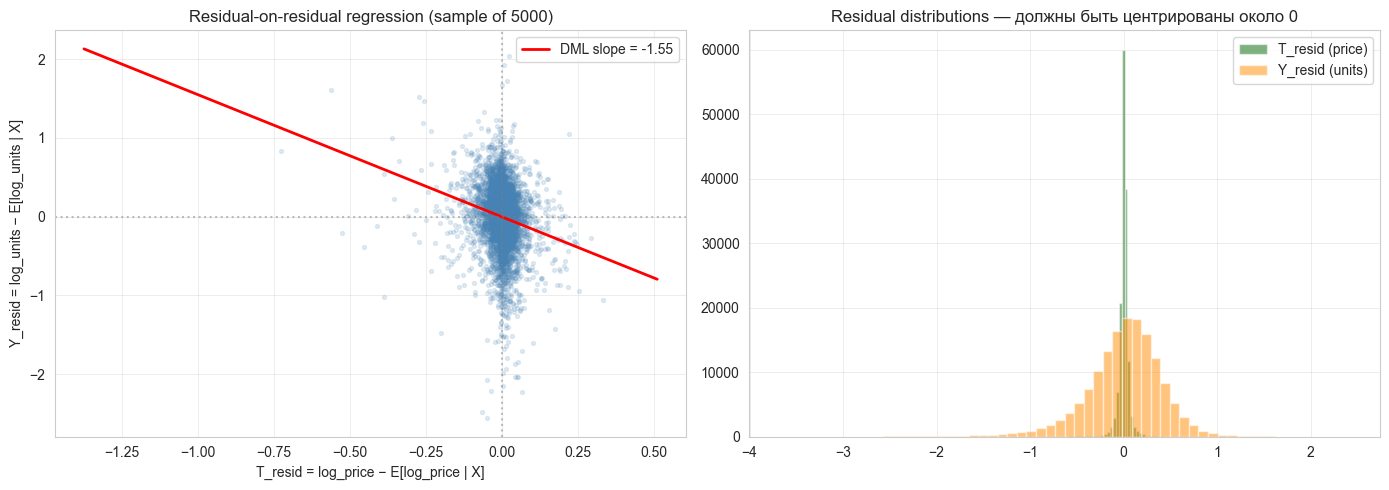

In [7]:
# === Cell 5: визуализация — финальная регрессия остатков ===

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Слева: scatter remaining variation
sample_idx = np.random.RandomState(42).choice(len(T_resid), size=5000, replace=False)
axes[0].scatter(T_resid[sample_idx], Y_resid[sample_idx], alpha=0.15, s=8, color='steelblue')
x_line = np.linspace(T_resid.min(), T_resid.max(), 100)
axes[0].plot(x_line, theta * x_line, color='red', linewidth=2,
             label=f'DML slope = {theta:.2f}')
axes[0].axhline(0, color='gray', linestyle=':', alpha=0.5)
axes[0].axvline(0, color='gray', linestyle=':', alpha=0.5)
axes[0].set_xlabel('T_resid = log_price − E[log_price | X]')
axes[0].set_ylabel('Y_resid = log_units − E[log_units | X]')
axes[0].set_title('Residual-on-residual regression (sample of 5000)')
axes[0].legend()

# Справа: распределения остатков
axes[1].hist(T_resid, bins=60, alpha=0.5, label='T_resid (price)', color='darkgreen')
axes[1].hist(Y_resid, bins=60, alpha=0.5, label='Y_resid (units)', color='darkorange')
axes[1].set_title('Residual distributions — должны быть центрированы около 0')
axes[1].legend()

plt.tight_layout()
plt.show()

In [8]:
# === Cell 6: DML — две версии (с promo в контролях и без) ===

def run_dml(X, T, Y, categorical, K=5, params=None, seed=42):
    """Запускает DML с K-fold cross-fitting. Возвращает theta, se, остатки, R²."""
    params = params or dict(
        n_estimators=300, learning_rate=0.05, num_leaves=31,
        min_child_samples=100, feature_fraction=0.8, random_state=seed,
    )
    kf = KFold(n_splits=K, shuffle=True, random_state=seed)
    y_hat = np.zeros(len(Y))
    t_hat = np.zeros(len(T))

    for train_idx, val_idx in kf.split(X):
        X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
        model_y = lgb.LGBMRegressor(**params, verbose=-1)
        model_y.fit(X_tr, Y.iloc[train_idx], categorical_feature=categorical)
        y_hat[val_idx] = model_y.predict(X_val)

        model_t = lgb.LGBMRegressor(**params, verbose=-1)
        model_t.fit(X_tr, T.iloc[train_idx], categorical_feature=categorical)
        t_hat[val_idx] = model_t.predict(X_val)

    Y_resid = Y.values - y_hat
    T_resid = T.values - t_hat

    # Final OLS
    ols = sm.OLS(Y_resid, T_resid.reshape(-1, 1)).fit()
    theta = ols.params[0]
    se = ols.bse[0]

    return {
        'theta': theta, 'se': se,
        'ci_low': theta - 1.96 * se, 'ci_high': theta + 1.96 * se,
        'r2_y': r2_score(Y, y_hat),
        'r2_t': r2_score(T, t_hat),
        'Y_resid': Y_resid, 'T_resid': T_resid,
        't_resid_std': T_resid.std(),
    }

# Модель A: с promo в контролях
CONTROLS_A = [
    'upc_code', 'store_code', 'manuf_code', 'subcat_code', 'seg_code',
    'size_oz', 'month', 'week_of_year', 'quarter', 'year', 'is_holiday_week',
    'promo_code',
    'SALES_AREA_SIZE_NUM', 'AVG_WEEKLY_BASKETS',
]
CAT_A = ['upc_code', 'store_code', 'manuf_code', 'subcat_code', 'seg_code', 'promo_code']

# Модель B: без promo в контролях
CONTROLS_B = [c for c in CONTROLS_A if c != 'promo_code']
CAT_B      = [c for c in CAT_A if c != 'promo_code']

print('Running Model A (with promo as control)...')
res_A = run_dml(df_dml[CONTROLS_A], df_dml['log_price'], df_dml['log_units'], CAT_A)

print('Running Model B (without promo as control)...')
res_B = run_dml(df_dml[CONTROLS_B], df_dml['log_price'], df_dml['log_units'], CAT_B)

# Сравнение
print('\n=== Results ===')
print(f'{"Metric":<30} {"Model A":>15} {"Model B":>15}')
print(f'{"  (promo in controls?)":<30} {"YES":>15} {"NO":>15}')
print('-' * 60)
print(f'{"θ (elasticity)":<30} {res_A["theta"]:>+15.3f} {res_B["theta"]:>+15.3f}')
print(f'{"Standard error":<30} {res_A["se"]:>15.3f} {res_B["se"]:>15.3f}')
print(f'{"95% CI":<30} '
      f'[{res_A["ci_low"]:+.2f}, {res_A["ci_high"]:+.2f}]   '
      f'[{res_B["ci_low"]:+.2f}, {res_B["ci_high"]:+.2f}]')
print(f'{"R² outcome model":<30} {res_A["r2_y"]:>15.3f} {res_B["r2_y"]:>15.3f}')
print(f'{"R² treatment model":<30} {res_A["r2_t"]:>15.3f} {res_B["r2_t"]:>15.3f}')
print(f'{"T_resid std":<30} {res_A["t_resid_std"]:>15.3f} {res_B["t_resid_std"]:>15.3f}')

print('\n=== Interpretation ===')
print('Model A: эластичность чистой цены при фиксированной промо-механике')
print('         → используется для micro-pricing (everyday price)')
print('Model B: эластичность "ценового пакета" (цена + промо вместе)')
print('         → используется для оценки полных промо-акций')

Running Model A (with promo as control)...
Running Model B (without promo as control)...

=== Results ===
Metric                                 Model A         Model B
  (promo in controls?)                     YES              NO
------------------------------------------------------------
θ (elasticity)                          -1.551          -2.666
Standard error                           0.019           0.014
95% CI                         [-1.59, -1.51]   [-2.69, -2.64]
R² outcome model                         0.791           0.698
R² treatment model                       0.958           0.903
T_resid std                              0.054           0.081

=== Interpretation ===
Model A: эластичность чистой цены при фиксированной промо-механике
         → используется для micro-pricing (everyday price)
Model B: эластичность "ценового пакета" (цена + промо вместе)
         → используется для оценки полных промо-акций


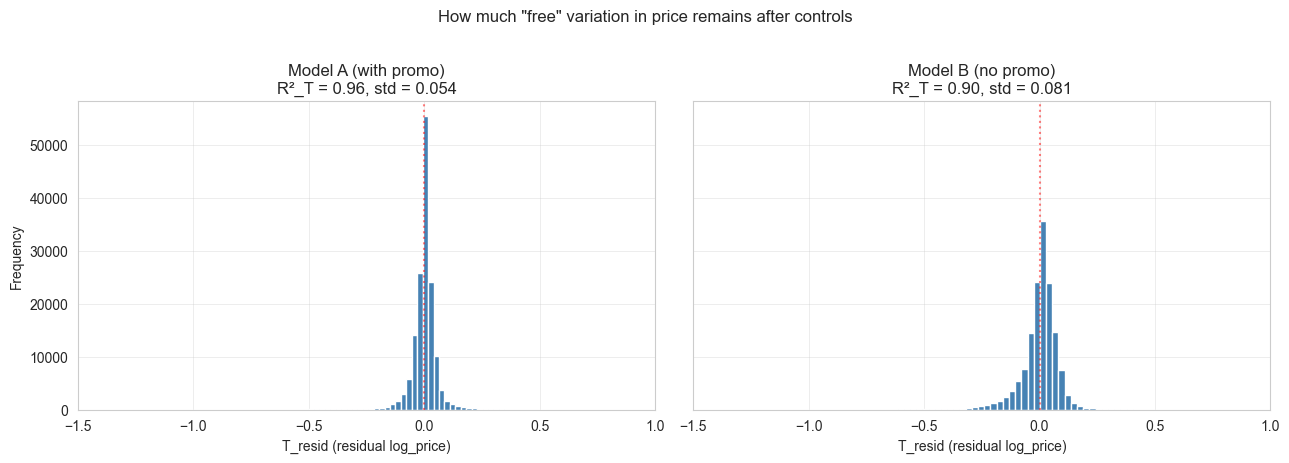

In [9]:
# === Cell 7: визуализация — как меняется overlap ===

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharey=True)

for ax, res, label in zip(axes, [res_A, res_B], ['Model A (with promo)', 'Model B (no promo)']):
    ax.hist(res['T_resid'], bins=80, color='steelblue', edgecolor='white')
    ax.axvline(0, color='red', linestyle=':', alpha=0.5)
    ax.set_xlabel('T_resid (residual log_price)')
    ax.set_title(f'{label}\nR²_T = {res["r2_t"]:.2f}, std = {res["t_resid_std"]:.3f}')
    ax.set_xlim(-1.5, 1.0)

axes[0].set_ylabel('Frequency')
plt.suptitle('How much "free" variation in price remains after controls', y=1.02)
plt.tight_layout()
plt.show()

In [11]:
# === Cell 8 (fixed): DML через EconML ===
import warnings
warnings.filterwarnings('ignore', category=UserWarning)  # глушим feature name warnings

from econml.dml import LinearDML

# Передаём контроли как numpy — чтобы избежать feature name warnings
W = df_dml[CONTROLS_B].values
T = df_dml['log_price'].values
Y = df_dml['log_units'].values

model_y_econml = lgb.LGBMRegressor(
    n_estimators=300, learning_rate=0.05, num_leaves=31,
    min_child_samples=100, feature_fraction=0.8, random_state=42, verbose=-1,
)
model_t_econml = lgb.LGBMRegressor(
    n_estimators=300, learning_rate=0.05, num_leaves=31,
    min_child_samples=100, feature_fraction=0.8, random_state=42, verbose=-1,
)

est = LinearDML(
    model_y=model_y_econml,
    model_t=model_t_econml,
    discrete_treatment=False,
    cv=5,
    random_state=42,
)

print('Fitting LinearDML...')
est.fit(Y, T, X=None, W=W)

# В EconML, когда X=None, эластичность хранится в intercept_, не в coef_
theta_econml = float(np.atleast_1d(est.intercept_)[0])

# Inference: доверительный интервал
intercept_inf = est.intercept__inference()
ci = intercept_inf.conf_int(alpha=0.05)
ci_low  = float(np.atleast_1d(ci[0])[0])
ci_high = float(np.atleast_1d(ci[1])[0])

print(f'\n=== EconML LinearDML result ===')
print(f'θ (elasticity)  : {theta_econml:+.3f}')
print(f'95% CI          : [{ci_low:+.3f}, {ci_high:+.3f}]')

print(f'\n=== Comparison ===')
print(f'Manual DML (Model B): -2.666 with CI [-2.69, -2.64]')
print(f'EconML LinearDML    : {theta_econml:+.3f} with CI [{ci_low:+.3f}, {ci_high:+.3f}]')

# Доп.summary от EconML — статистический отчёт
print('\n=== EconML summary ===')
print(est.summary())

Fitting LinearDML...

=== EconML LinearDML result ===
θ (elasticity)  : -2.626
95% CI          : [-2.677, -2.574]

=== Comparison ===
Manual DML (Model B): -2.666 with CI [-2.69, -2.64]
EconML LinearDML    : -2.626 with CI [-2.677, -2.574]

=== EconML summary ===
Coefficient Results:  X is None, please call intercept_inference to learn the constant!
                        CATE Intercept Results                        
               point_estimate stderr  zstat   pvalue ci_lower ci_upper
----------------------------------------------------------------------
cate_intercept         -2.626  0.026 -100.212    0.0   -2.677   -2.574
----------------------------------------------------------------------

<sub>A linear parametric conditional average treatment effect (CATE) model was fitted:
$Y = \Theta(X)\cdot T + g(X, W) + \epsilon$
where for every outcome $i$ and treatment $j$ the CATE $\Theta_{ij}(X)$ has the form:
$\Theta_{ij}(X) = X' coef_{ij} + cate\_intercept_{ij}$
Coefficient Results 

In [ ]:
# Method                            Elasticity      CI / Status
# ────────────────────────────────────────────────────────────────────
# Pool OLS (M1)                     −0.56           naive, biased
# GBM PDP                           −0.43           biased (multicoll.)
# Per-SKU OLS (median)              −2.51           biased (omits promo)
# OLS + UPC + store + time          −2.84           biased (overshoots)
# OLS + promo (M4)                  −1.76           best linear, still biased
# ────────────────────────────────────────────────────────────────────
# DML Model A (promo as control)    −1.55           net-price elasticity
# DML Model B manual                −2.67  [−2.69, −2.64]   ← пакетная
# DML Model B EconML LinearDML      −2.63  [−2.68, −2.57]   ← пакетная + correct SE
# ────────────────────────────────────────────────────────────────────
# Literature for cereal:            −2.0 to −3.5

In [12]:
# === Cell 9: CausalForestDML — гетерогенная эластичность ===
import warnings
warnings.filterwarnings('ignore')

from econml.dml import CausalForestDML

# Что разделяет X (effect modifiers) от W (nuisance controls):
# - X: переменные, по которым ожидаем разную эластичность (бренд, сегмент, размер)
# - W: остальные контроли (магазин/время/SKU-фиксы)
#
# Чем меньше effect modifiers, тем стабильнее оценка. Возьмём минимальный набор:
EFFECT_MODIFIERS = [
    'manuf_code',     # бренд → разные эластичности у Cheerios/Froot Loops/private label
    'subcat_code',    # adult/kids/all-family
    'seg_code',       # VALUE/MAINSTREAM/UPSCALE
    'size_oz',        # размер упаковки
]

# Всё остальное — в nuisance controls
NUISANCE_CONTROLS = [c for c in CONTROLS_B if c not in EFFECT_MODIFIERS]

X = df_dml[EFFECT_MODIFIERS].values
W = df_dml[NUISANCE_CONTROLS].values
T = df_dml['log_price'].values
Y = df_dml['log_units'].values

print(f'Effect modifiers (X): {EFFECT_MODIFIERS}')
print(f'Nuisance controls (W): {NUISANCE_CONTROLS}')
print(f'Shapes: X={X.shape}, W={W.shape}')

# Те же nuisance-модели, что раньше
model_y_cf = lgb.LGBMRegressor(
    n_estimators=300, learning_rate=0.05, num_leaves=31,
    min_child_samples=100, feature_fraction=0.8, random_state=42, verbose=-1,
)
model_t_cf = lgb.LGBMRegressor(
    n_estimators=300, learning_rate=0.05, num_leaves=31,
    min_child_samples=100, feature_fraction=0.8, random_state=42, verbose=-1,
)

cf_dml = CausalForestDML(
    model_y=model_y_cf,
    model_t=model_t_cf,
    discrete_treatment=False,
    n_estimators=200,         # количество деревьев в лесу для CATE
    min_samples_leaf=200,     # минимум наблюдений в листе — стабилизация
    max_depth=None,
    cv=5,
    random_state=42,
)

print('\nFitting CausalForestDML (это займёт пару минут)...')
cf_dml.fit(Y, T, X=X, W=W)
print('Done.')

# Оценим эластичность на исходных данных
cate_estimates = cf_dml.effect(X)
print(f'\n=== CATE distribution ===')
print(f'Mean elasticity   : {cate_estimates.mean():+.3f}')
print(f'Median elasticity : {np.median(cate_estimates):+.3f}')
print(f'Std               : {cate_estimates.std():.3f}')
print(f'Min / Max         : {cate_estimates.min():+.3f} / {cate_estimates.max():+.3f}')
print(f'5% / 95% percentile: {np.percentile(cate_estimates, 5):+.3f} / {np.percentile(cate_estimates, 95):+.3f}')

# Compare with LinearDML
print(f'\nLinearDML (constant) : -2.626')
print(f'CausalForest mean    : {cate_estimates.mean():+.3f}')
print(f'(если сильно отличаются — есть существенная гетерогенность)')

Effect modifiers (X): ['manuf_code', 'subcat_code', 'seg_code', 'size_oz']
Nuisance controls (W): ['upc_code', 'store_code', 'month', 'week_of_year', 'quarter', 'year', 'is_holiday_week', 'SALES_AREA_SIZE_NUM', 'AVG_WEEKLY_BASKETS']
Shapes: X=(150672, 4), W=(150672, 9)

Fitting CausalForestDML (это займёт пару минут)...
Done.

=== CATE distribution ===
Mean elasticity   : -2.619
Median elasticity : -2.570
Std               : 0.868
Min / Max         : -4.866 / -0.530
5% / 95% percentile: -4.671 / -0.746

LinearDML (constant) : -2.626
CausalForest mean    : -2.619
(если сильно отличаются — есть существенная гетерогенность)


In [13]:
# === Cell 10: гетерогенность по бренду, сегменту, подкатегории ===

# Прикрепим CATE к датафрейму
analysis_df = df_dml.copy()
analysis_df['cate'] = cate_estimates

# 1) По бренду
print('=== Elasticity by MANUFACTURER ===')
by_brand = analysis_df.groupby('MANUFACTURER').agg(
    n=('cate', 'size'),
    mean_elasticity=('cate', 'mean'),
    median_elasticity=('cate', 'median'),
    std=('cate', 'std'),
).round(3).sort_values('mean_elasticity')
print(by_brand)

# 2) По подкатегории
print('\n=== Elasticity by SUB_CATEGORY ===')
by_subcat = analysis_df.groupby('SUB_CATEGORY').agg(
    n=('cate', 'size'),
    mean_elasticity=('cate', 'mean'),
    median_elasticity=('cate', 'median'),
    std=('cate', 'std'),
).round(3).sort_values('mean_elasticity')
print(by_subcat)

# 3) По сегменту магазина
print('\n=== Elasticity by STORE SEGMENT ===')
by_segment = analysis_df.groupby('SEG_VALUE_NAME').agg(
    n=('cate', 'size'),
    mean_elasticity=('cate', 'mean'),
    median_elasticity=('cate', 'median'),
    std=('cate', 'std'),
).round(3).sort_values('mean_elasticity')
print(by_segment)

# 4) По бренду × сегменту — самая бизнес-релевантная разбивка
print('\n=== Elasticity by MANUFACTURER × SEGMENT ===')
by_brand_segment = analysis_df.groupby(['MANUFACTURER', 'SEG_VALUE_NAME']).agg(
    n=('cate', 'size'),
    mean_elasticity=('cate', 'mean'),
).round(3).reset_index()
print(by_brand_segment.pivot(index='MANUFACTURER', columns='SEG_VALUE_NAME',
                               values='mean_elasticity'))

# 5) Per-SKU
print('\n=== Elasticity by SKU (top-15) ===')
by_sku = analysis_df.groupby(['UPC', 'DESCRIPTION', 'MANUFACTURER']).agg(
    n=('cate', 'size'),
    mean_elasticity=('cate', 'mean'),
).round(3).reset_index().sort_values('mean_elasticity')
print(by_sku.to_string(index=False))

=== Elasticity by MANUFACTURER ===
                   n  mean_elasticity  median_elasticity    std
MANUFACTURER                                                   
KELLOGG        31216           -3.240             -2.799  0.958
QUAKER         30343           -3.166             -3.391  0.463
POST FOODS     26480           -2.531             -2.502  0.441
PRIVATE LABEL  31304           -2.128             -2.086  0.262
GENERAL MI     31329           -2.037             -2.570  1.004

=== Elasticity by SUB_CATEGORY ===
                       n  mean_elasticity  median_elasticity    std
SUB_CATEGORY                                                       
KIDS CEREAL        49770           -3.307             -2.976  0.770
ADULT CEREAL       28370           -2.302             -2.357  0.270
ALL FAMILY CEREAL  72532           -2.271             -2.346  0.803

=== Elasticity by STORE SEGMENT ===
                    n  mean_elasticity  median_elasticity    std
SEG_VALUE_NAME                         

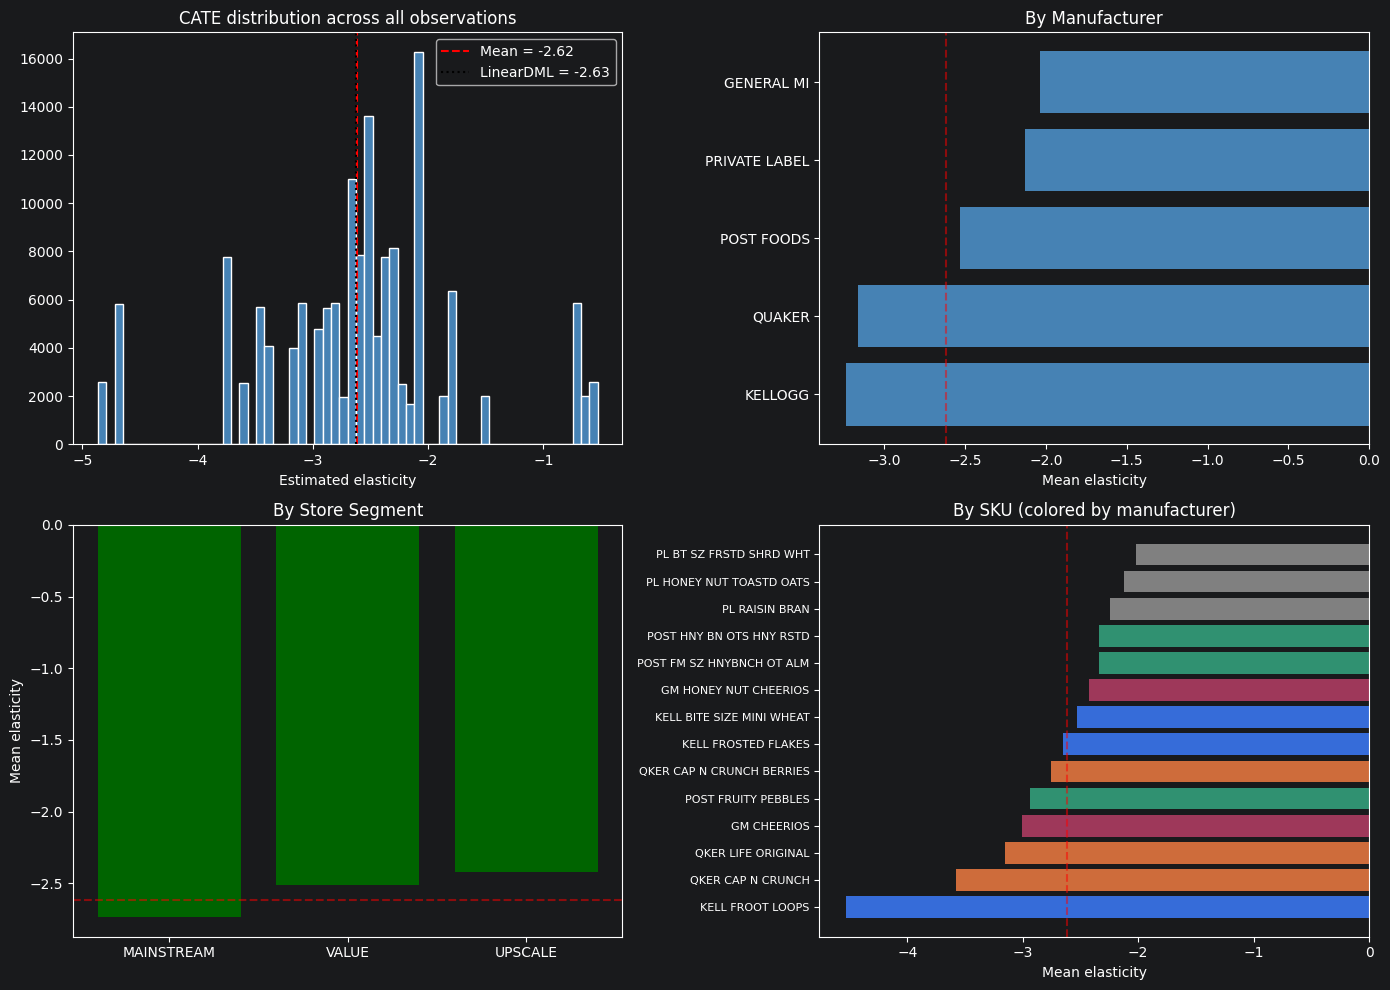

In [14]:
# === Cell 11: визуализация гетерогенности ===
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1) Распределение CATE
axes[0, 0].hist(cate_estimates, bins=60, color='steelblue', edgecolor='white')
axes[0, 0].axvline(cate_estimates.mean(), color='red', linestyle='--',
                    label=f'Mean = {cate_estimates.mean():.2f}')
axes[0, 0].axvline(-2.626, color='black', linestyle=':',
                    label=f'LinearDML = -2.63')
axes[0, 0].set_xlabel('Estimated elasticity')
axes[0, 0].set_title('CATE distribution across all observations')
axes[0, 0].legend()

# 2) По бренду
sorted_brands = by_brand.index
axes[0, 1].barh(sorted_brands, by_brand['mean_elasticity'], color='steelblue')
axes[0, 1].axvline(cate_estimates.mean(), color='red', linestyle='--', alpha=0.5)
axes[0, 1].set_xlabel('Mean elasticity')
axes[0, 1].set_title('By Manufacturer')

# 3) По сегменту магазина
sorted_segs = by_segment.index
axes[1, 0].bar(sorted_segs, by_segment['mean_elasticity'], color='darkgreen')
axes[1, 0].axhline(cate_estimates.mean(), color='red', linestyle='--', alpha=0.5)
axes[1, 0].set_ylabel('Mean elasticity')
axes[1, 0].set_title('By Store Segment')

# 4) По SKU (только бренды, для читаемости)
sku_sorted = by_sku.sort_values('mean_elasticity')
colors = {'KELLOGG': 'C0', 'QUAKER': 'C1', 'GENERAL MI': 'C2',
          'POST FOODS': 'C3', 'PRIVATE LABEL': 'gray'}
bar_colors = [colors.get(m, 'gray') for m in sku_sorted['MANUFACTURER']]
axes[1, 1].barh(sku_sorted['DESCRIPTION'], sku_sorted['mean_elasticity'], color=bar_colors)
axes[1, 1].axvline(cate_estimates.mean(), color='red', linestyle='--', alpha=0.5)
axes[1, 1].set_xlabel('Mean elasticity')
axes[1, 1].set_title('By SKU (colored by manufacturer)')
axes[1, 1].tick_params(axis='y', labelsize=8)

plt.tight_layout()
plt.show()

In [17]:
# === Cell 12: сохранение артефактов DML ===
import joblib

ARTIFACTS = Path('data') / 'artifacts'
ARTIFACTS.mkdir(parents=True, exist_ok=True)

# Модель CausalForestDML
joblib.dump(cf_dml, ARTIFACTS / 'cf_dml.pkl')

# Модель LinearDML
joblib.dump(est, ARTIFACTS / 'linear_dml.pkl')

# Таблица CATE на train-данных
cate_table = analysis_df[[
    'WEEK_END_DATE', 'STORE_NUM', 'UPC', 'DESCRIPTION', 'MANUFACTURER',
    'SUB_CATEGORY', 'SEG_VALUE_NAME', 'size_oz',
    'PRICE', 'BASE_PRICE', 'UNITS', 'log_price', 'log_units',
    'cate',
]].copy()
cate_table.to_parquet(ARTIFACTS / 'cate_train.parquet', index=False)

# Лучшая оценка эластичности по SKU
elasticity_by_sku = by_sku.copy()
elasticity_by_sku.to_csv(ARTIFACTS / 'elasticity_by_sku.csv', index=False)

# Summary всех оценок проекта
summary = pd.DataFrame([
    {'method': 'Pool OLS (M1)',                     'elasticity': -0.56, 'note': 'naive'},
    {'method': 'Per-SKU OLS (median)',              'elasticity': -2.51, 'note': 'within-SKU'},
    {'method': 'OLS + UPC FE (M2)',                 'elasticity': -2.59, 'note': 'biased'},
    {'method': 'OLS + UPC + store + time (M3)',     'elasticity': -2.84, 'note': 'biased'},
    {'method': 'OLS + promo (M4)',                  'elasticity': -1.76, 'note': 'best linear'},
    {'method': 'GBM PDP (naive)',                   'elasticity': -0.43, 'note': 'multicollinearity'},
    {'method': 'DML Manual Model A (with promo)',   'elasticity': -1.55, 'note': 'net-price'},
    {'method': 'DML Manual Model B (no promo)',     'elasticity': -2.67, 'note': 'price+promo bundle'},
    {'method': 'EconML LinearDML',                  'elasticity': -2.63, 'note': 'price+promo, correct SE'},
    {'method': 'CausalForestDML (mean)',            'elasticity': -2.62, 'note': 'heterogeneous'},
])
summary.to_csv(ARTIFACTS / 'all_elasticity_estimates.csv', index=False)

print('Saved artifacts:')
for f in sorted(ARTIFACTS.iterdir()):
    print(f'  {f.name}: {f.stat().st_size / 1024:.1f} KB')

Saved artifacts:
  all_elasticity_estimates.csv: 0.4 KB
  cate_train.parquet: 771.2 KB
  cf_dml.pkl: 12375.7 KB
  elasticity_by_sku.csv: 0.8 KB
  linear_dml.pkl: 8811.9 KB
